# Analisis Penjualan — Showcase Revisi

Notebook ini menyajikan exploratory data analysis (EDA) penjualan dengan alur yang lebih ringkas, validasi yang lebih defensible, dan visual editorial yang lebih siap untuk showcase.

**Pertanyaan utama:** produk, waktu, lokasi, dan segmen pelanggan mana yang paling berkontribusi terhadap nilai penjualan?

**Sumber data:** `customers.csv`, `products.csv`, dan `sales.csv`.

> Jalankan notebook dari atas ke bawah. Path dataset dibuat configurable di sel setup agar notebook tetap mudah dipindahkan ke folder `data/` atau lingkungan lain.

### Ringkasan revisi dari V2

- Menghapus dependensi upload/download Google Colab dan menggantinya dengan konfigurasi path yang reproducible.
- Membersihkan angka dan tanggal sebelum analisis; nilai teks `fifty` dikonversi menjadi `50` sebelum coercion numerik.
- Menormalkan variasi lokasi dan kategori gender.
- Mengkanonisasi customer dimension menjadi satu baris per ID agar join tidak mengalami many-to-many row explosion.
- Mempertahankan retur, customer yang tidak ditemukan, dan produk yang tidak diketahui sebagai bagian dari data-quality story.
- Mengganti pie chart dan visual default dengan KPI cards, ranked bars, trend view, stacked composition, dan heatmap yang lebih mudah dibaca.

In [1]:
# 1. Setup, load, dan cleaning
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, PercentFormatter
from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")

# Palet editorial yang tenang dengan satu aksen untuk highlight.
PALETTE = {
    "ink": "#17213B",
    "blue": "#457B9D",
    "teal": "#2A9D8F",
    "coral": "#E76F51",
    "gold": "#F4A261",
    "muted": "#6B7280",
    "grid": "#D9E2EC",
    "paper": "#F7F6F2",
    "white": "#FFFFFF",
    "unknown": "#A8B2BE",
}

sns.set_theme(style="white", context="notebook")
plt.rcParams.update(
    {
        "figure.facecolor": PALETTE["paper"],
        "axes.facecolor": PALETTE["paper"],
        "axes.edgecolor": PALETTE["grid"],
        "axes.labelcolor": PALETTE["ink"],
        "axes.titlecolor": PALETTE["ink"],
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "font.size": 10.5,
        "font.family": "DejaVu Sans",
        "xtick.color": PALETTE["muted"],
        "ytick.color": PALETTE["muted"],
        "grid.color": PALETTE["grid"],
        "grid.linewidth": 0.8,
        "savefig.facecolor": PALETTE["paper"],
    }
)

DATA_DIR_CANDIDATES = [
    Path("data"),
    Path(
        "/Users/daffa/Library/Mobile Documents/com~apple~CloudDocs/"
        "University/7th/Sertifikasi/Studi Kasus/"
        "Dataset Tugas Praktik Data Analyst"
    ),
    Path.cwd() / "data",
]
DATA_DIR = next(
    (
        candidate
        for candidate in DATA_DIR_CANDIDATES
        if all((candidate / filename).exists() for filename in [
            "customers.csv", "products.csv", "sales.csv"
        ])
    ),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset tidak ditemukan. Letakkan tiga CSV di folder data/ "
        "atau ubah DATA_DIR_CANDIDATES."
    )

customers_raw = pd.read_csv(DATA_DIR / "customers.csv")
products_raw = pd.read_csv(DATA_DIR / "products.csv")
sales_raw = pd.read_csv(DATA_DIR / "sales.csv")

def normalize_gender(value):
    if pd.isna(value):
        return "Unknown"
    value = str(value).strip().lower()
    return {
        "pria": "Pria",
        "laki-laki": "Pria",
        "wanita": "Wanita",
        "perempuan": "Wanita",
        "other": "Unknown",
        "tidak diketahui": "Unknown",
        "unknown": "Unknown",
        "nan": "Unknown",
    }.get(value, "Unknown")

def normalize_location(value):
    if pd.isna(value):
        return "Unknown"
    value = str(value).strip()
    return {
        "BDG": "Bandung",
        "Bandung": "Bandung",
        "DI Yogyakarta": "Yogyakarta",
        "Yogyakarta": "Yogyakarta",
        "DKI Jakarta": "Jakarta",
        "Jakarta": "Jakarta",
        "Makasar": "Makassar",
        "Makassar": "Makassar",
    }.get(value, value if value else "Unknown")

def stable_mode(series):
    values = series.dropna().astype(str)
    if values.empty:
        return "Unknown"
    return values.value_counts().sort_values(
        ascending=False, kind="stable"
    ).index[0]

def short_number(value):
    value = float(value)
    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if abs(value) >= 1_000:
        return f"{value / 1_000:.1f}k"
    return f"{value:,.0f}"

def format_number(value):
    return f"{float(value):,.0f}".replace(",", ".")

def clean_axes(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(PALETTE["grid"])
    ax.tick_params(axis="both", length=0)
    ax.grid(axis=grid_axis, color=PALETTE["grid"], linewidth=0.8)
    ax.set_axisbelow(True)

# Customer dimension: validasi umur, normalisasi kategori, lalu deduplikasi.
customers = customers_raw.copy()
customers["ID Pelanggan"] = customers["ID Pelanggan"].astype(str).str.strip()
customers["Usia"] = pd.to_numeric(
    customers["Usia"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
)
customers.loc[~customers["Usia"].between(10, 100), "Usia"] = np.nan
customers["Jenis Kelamin"] = customers["Jenis Kelamin"].map(normalize_gender)
customers["Lokasi"] = customers["Lokasi"].map(normalize_location)

customer_group = customers.groupby("ID Pelanggan")
customer_variant_table = customer_group.agg(
    usia_variants=("Usia", lambda s: s.dropna().nunique()),
    gender_variants=("Jenis Kelamin", "nunique"),
    lokasi_variants=("Lokasi", "nunique"),
)
duplicate_customer_ids = int((customer_group.size() > 1).sum())
conflicting_customer_ids = int(
    (customer_variant_table > 1).any(axis=1).sum()
)

customer_dim = customer_group.agg(
    Usia=("Usia", "median"),
    **{
        "Jenis Kelamin": ("Jenis Kelamin", stable_mode),
        "Lokasi": ("Lokasi", stable_mode),
    },
).reset_index()
customer_dim["Customer Records"] = customer_group.size().values

# Sales: perbaiki string numerik sebelum melakukan kalkulasi.
sales = sales_raw.copy()
sales["ID Pelanggan"] = sales["ID Pelanggan"].astype(str).str.strip()
sales["Tanggal Transaksi"] = pd.to_datetime(
    sales["Tanggal Transaksi"], errors="coerce", format="mixed"
)
sales["Kuantitas"] = pd.to_numeric(sales["Kuantitas"], errors="coerce")
price_text = sales["Harga per Unit"].astype(str).str.strip().str.lower()
repaired_price_rows = int(price_text.eq("fifty").sum())
price_text = price_text.replace({"fifty": "50"})
sales["Harga per Unit"] = pd.to_numeric(price_text, errors="coerce")
sales["Produk"] = sales["Produk"].fillna("Produk Tidak Diketahui").astype(str).str.strip()
sales.loc[sales["Produk"].isin(["", "nan", "None"]), "Produk"] = "Produk Tidak Diketahui"

products = products_raw.copy()
products["Nama Produk"] = products["Nama Produk"].astype(str).str.strip()

# Baris valid dipakai untuk metrik utama; retur tetap dipertahankan sebagai nilai negatif.
valid_transaction_mask = (
    sales["Tanggal Transaksi"].notna()
    & sales["Kuantitas"].notna()
    & sales["Harga per Unit"].notna()
    & sales["Kuantitas"].ne(0)
)
sales_valid = sales.loc[valid_transaction_mask].copy()
sales_valid = sales_valid.merge(
    customer_dim,
    on="ID Pelanggan",
    how="left",
    validate="many_to_one",
    indicator="customer_match",
)
sales_valid["Usia"] = sales_valid["Usia"].fillna(np.nan)
sales_valid["Jenis Kelamin"] = sales_valid["Jenis Kelamin"].fillna("Unknown")
sales_valid["Lokasi"] = sales_valid["Lokasi"].fillna("Unknown")
sales_valid = sales_valid.merge(
    products,
    left_on="Produk",
    right_on="Nama Produk",
    how="left",
    validate="many_to_one",
    indicator="product_match",
)
sales_valid["Nilai Transaksi"] = sales_valid["Kuantitas"] * sales_valid["Harga per Unit"]
sales_valid["Penjualan Bruto"] = sales_valid["Nilai Transaksi"].where(
    sales_valid["Kuantitas"] > 0, 0
)
sales_valid["Nilai Retur"] = (-sales_valid["Nilai Transaksi"]).where(
    sales_valid["Kuantitas"] < 0, 0
)
sales_valid["Unit Terjual"] = sales_valid["Kuantitas"].where(
    sales_valid["Kuantitas"] > 0, 0
)
sales_valid["Unit Retur"] = (-sales_valid["Kuantitas"]).where(
    sales_valid["Kuantitas"] < 0, 0
)
sales_valid["Status Transaksi"] = np.where(
    sales_valid["Kuantitas"] < 0, "Retur", "Penjualan"
)
sales_valid["Periode"] = sales_valid["Tanggal Transaksi"].dt.to_period("M").dt.to_timestamp()

age_bins = [0, 20, 30, 40, 50, 60, np.inf]
age_labels = ["<20", "20–29", "30–39", "40–49", "50–59", "60+"]
sales_valid["Kelompok Usia"] = pd.cut(
    sales_valid["Usia"], bins=age_bins, labels=age_labels, right=False
)
sales_valid["Kelompok Usia"] = sales_valid["Kelompok Usia"].cat.add_categories("Unknown").fillna("Unknown")

data_start = sales_valid["Tanggal Transaksi"].min()
data_end = sales_valid["Tanggal Transaksi"].max()
latest_period_is_partial = data_end.day < data_end.days_in_month
latest_period_note = (
    f"Periode terakhir hanya sampai {data_end.strftime('%d %b %Y')}"
    if latest_period_is_partial
    else "Periode terakhir mencakup seluruh bulan"
)

gross_sales = sales_valid.loc[sales_valid["Kuantitas"] > 0].copy()
return_sales = sales_valid.loc[sales_valid["Kuantitas"] < 0].copy()

# Ringkasan analitis yang dipakai di visual.
product_summary = gross_sales.groupby("Produk").agg(
    Penjualan=("Penjualan Bruto", "sum"),
    Unit=("Unit Terjual", "sum"),
    Transaksi=("Produk", "size"),
).sort_values("Penjualan", ascending=False)
known_product_summary = product_summary.loc[
    product_summary.index != "Produk Tidak Diketahui"
].copy()
known_product_summary["Kontribusi (%)"] = (
    known_product_summary["Penjualan"]
    / known_product_summary["Penjualan"].sum()
    * 100
)

location_summary = sales_valid.groupby("Lokasi").agg(
    **{
        "Penjualan Bersih": ("Nilai Transaksi", "sum"),
        "Penjualan Bruto": ("Penjualan Bruto", "sum"),
        "Transaksi Positif": ("Penjualan Bruto", lambda s: int((s > 0).sum())),
    }
).sort_values("Penjualan Bersih", ascending=False)

monthly_summary = sales_valid.groupby("Periode").agg(
    **{
        "Penjualan Bruto": ("Penjualan Bruto", "sum"),
        "Nilai Retur": ("Nilai Retur", "sum"),
        "Penjualan Bersih": ("Nilai Transaksi", "sum"),
        "Unit Terjual": ("Unit Terjual", "sum"),
        "Unit Retur": ("Unit Retur", "sum"),
    }
).sort_index()
monthly_summary["Return Rate (%)"] = np.where(
    monthly_summary["Unit Terjual"] > 0,
    monthly_summary["Unit Retur"] / monthly_summary["Unit Terjual"] * 100,
    0,
)

age_order = age_labels + ["Unknown"]
segment_summary = (
    gross_sales.groupby(["Kelompok Usia", "Jenis Kelamin"], observed=False)["Penjualan Bruto"]
    .sum()
    .unstack(fill_value=0)
    .reindex(age_order)
    .fillna(0)
)

heatmap_data = gross_sales.loc[
    gross_sales["Produk"] != "Produk Tidak Diketahui"
].pivot_table(
    index="Produk", columns="Lokasi", values="Penjualan Bruto", aggfunc="sum", fill_value=0
)
heatmap_data = heatmap_data.reindex(
    index=known_product_summary.index,
    columns=location_summary.index,
    fill_value=0,
)

# KPI inti dan data-quality counts.
gross_value = gross_sales["Penjualan Bruto"].sum()
returns_value = return_sales["Nilai Retur"].sum()
net_value = sales_valid["Nilai Transaksi"].sum()
units_sold = gross_sales["Unit Terjual"].sum()
units_returned = return_sales["Unit Retur"].sum()
return_rate = units_returned / units_sold * 100 if units_sold else 0
positive_transactions = len(gross_sales)
unique_buyers = gross_sales["ID Pelanggan"].nunique()
invalid_date_rows = int(sales["Tanggal Transaksi"].isna().sum())
missing_quantity_rows = int(sales["Kuantitas"].isna().sum())
missing_product_rows = int((sales["Produk"] == "Produk Tidak Diketahui").sum())
unmatched_customer_rows = int((sales_valid["customer_match"] == "left_only").sum())
unknown_product_valid_rows = int((sales_valid["product_match"] == "left_only").sum())
exact_duplicate_sales_rows = int(sales_raw.duplicated().sum())
negative_quantity_rows = int((sales["Kuantitas"] < 0).sum())

source_shapes = pd.DataFrame(
    {
        "Dataset": ["customers", "products", "sales"],
        "Baris": [len(customers_raw), len(products_raw), len(sales_raw)],
        "Kolom": [customers_raw.shape[1], products_raw.shape[1], sales_raw.shape[1]],
    }
)
print(f"Dataset ditemukan di: {DATA_DIR}")
print(f"Transaksi valid untuk analisis: {len(sales_valid):,}")
print(f"Transaksi positif: {positive_transactions:,} | Retur: {len(return_sales):,}")

Dataset ditemukan di: /Users/daffa/Library/Mobile Documents/com~apple~CloudDocs/University/7th/Sertifikasi/Studi Kasus/Dataset Tugas Praktik Data Analyst
Transaksi valid untuk analisis: 10,236
Transaksi positif: 10,135 | Retur: 101


## TL;DR

Ringkasan berikut dihitung langsung dari pipeline di atas sehingga angka dan takeaways ikut berubah bila dataset diganti.

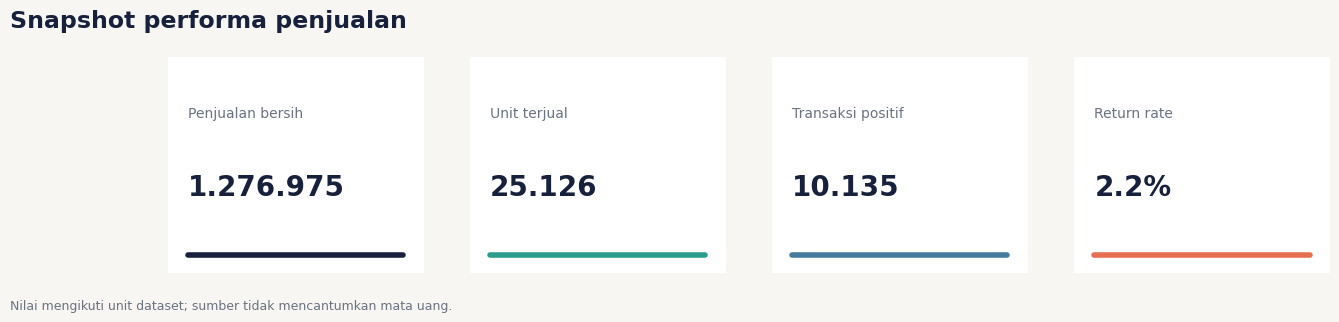


- **Sweater** adalah produk teratas dengan kontribusi **18.3%** di antara produk yang teridentifikasi.
- **Semarang** menjadi lokasi dengan penjualan bersih terbesar; puncak bulanan terjadi pada **Mar 2016**.
- Retur dipertahankan dalam perhitungan bersih: **28.846** nilai retur dari **548** unit.
- **90** baris sumber tidak memiliki nama produk dan **575** baris transaksi valid tidak menemukan customer master; keduanya tidak dihapus diam-diam.


In [2]:
# 2. Executive snapshot
kpis = [
    ("Penjualan bersih", format_number(net_value), PALETTE["ink"]),
    ("Unit terjual", format_number(units_sold), PALETTE["teal"]),
    ("Transaksi positif", format_number(positive_transactions), PALETTE["blue"]),
    ("Return rate", f"{return_rate:.1f}%", PALETTE["coral"]),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 2.8), facecolor=PALETTE["paper"])
fig.subplots_adjust(wspace=0.18)
for ax, (label, value, accent) in zip(axes, kpis):
    ax.set_facecolor(PALETTE["white"])
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.axhline(0.08, color=accent, linewidth=4, xmin=0.08, xmax=0.92)
    ax.text(0.08, 0.72, label, transform=ax.transAxes, color=PALETTE["muted"], fontsize=10)
    ax.text(0.08, 0.36, value, transform=ax.transAxes, color=PALETTE["ink"], fontsize=20, fontweight="bold")
fig.suptitle("Snapshot performa penjualan", x=0.02, y=1.05, ha="left", fontsize=17, fontweight="bold", color=PALETTE["ink"])
fig.text(0.02, -0.02, "Nilai mengikuti unit dataset; sumber tidak mencantumkan mata uang.", color=PALETTE["muted"], fontsize=9)
plt.show()

top_product = known_product_summary.index[0]
top_product_share = known_product_summary.iloc[0]["Kontribusi (%)"]
top_location = location_summary.index[0]
peak_month = monthly_summary["Penjualan Bersih"].idxmax().strftime("%b %Y")
display(
    Markdown(
        f'''
- **{top_product}** adalah produk teratas dengan kontribusi **{top_product_share:.1f}%** di antara produk yang teridentifikasi.
- **{top_location}** menjadi lokasi dengan penjualan bersih terbesar; puncak bulanan terjadi pada **{peak_month}**.
- Retur dipertahankan dalam perhitungan bersih: **{format_number(returns_value)}** nilai retur dari **{format_number(units_returned)}** unit.
- **{missing_product_rows:,}** baris sumber tidak memiliki nama produk dan **{unmatched_customer_rows:,}** baris transaksi valid tidak menemukan customer master; keduanya tidak dihapus diam-diam.
'''
    )
)

## Context & Methods

Notebook ini menggunakan grain **satu baris = satu record transaksi**. Nilai transaksi dihitung sebagai `Kuantitas × Harga per Unit`.

### Key assumptions

- Quantity positif diperlakukan sebagai penjualan; quantity negatif diperlakukan sebagai retur.
- Nilai `fifty` pada harga diperlakukan sebagai angka `50`, mengikuti cleaning rule pada notebook awal.
- Customer ID yang muncul lebih dari sekali dikonsolidasikan menjadi satu dimensi: median untuk umur dan mode stabil untuk gender/lokasi. Ini mencegah row multiplication saat join, tetapi konflik master tetap dicatat.
- Record tanpa tanggal, quantity, price, atau quantity nol tidak masuk ke metrik utama. Record produk tidak diketahui tetap masuk ke total keseluruhan, tetapi dikeluarkan dari ranking produk.
- Karena sumber tidak memiliki transaction ID, exact duplicate rows tidak dihapus otomatis.

In [3]:
# 3. Data-quality snapshot
quality_snapshot = pd.DataFrame(
    [
        ("Baris sales mentah", len(sales_raw), "Referensi"),
        ("Rentang tanggal valid", f"{data_start:%d %b %Y} – {data_end:%d %b %Y}", latest_period_note),
        ("Tanggal tidak valid / kosong", invalid_date_rows, "Dikeluarkan dari metrik waktu"),
        ("Quantity tidak terbaca", missing_quantity_rows, "Dikeluarkan dari metrik utama"),
        ("Quantity negatif / retur", negative_quantity_rows, "Dipertahankan sebagai retur"),
        ("Produk tidak diketahui", missing_product_rows, "Dipertahankan; tidak di-ranking"),
        ("Harga 'fifty' diperbaiki", repaired_price_rows, "Dikonversi menjadi 50"),
        ("ID customer duplikat", duplicate_customer_ids, "Dikonsolidasikan sebelum join"),
        ("ID customer dengan konflik atribut", conflicting_customer_ids, "Ditandai; mode/median dipakai"),
        ("Transaksi valid tanpa customer master", unmatched_customer_rows, "Customer = Unknown"),
        ("Transaksi valid tanpa product master", unknown_product_valid_rows, "Produk = Unknown"),
        ("Exact duplicate sales rows", exact_duplicate_sales_rows, "Tidak dihapus otomatis"),
    ],
    columns=["Pemeriksaan", "Jumlah", "Perlakuan"],
)
display(quality_snapshot)

,Pemeriksaan,Jumlah,Perlakuan
0,Baris sales mentah,10400,Referensi
1,Rentang tanggal valid,01 Jan 2014 – 16 Feb 2023,Periode terakhir hanya sampai 16 Feb 2023
2,Tanggal tidak valid / kosong,50,Dikeluarkan dari metrik waktu
3,Quantity tidak terbaca,115,Dikeluarkan dari metrik utama
4,Quantity negatif / retur,102,Dipertahankan sebagai retur
5,Produk tidak diketahui,90,Dipertahankan; tidak di-ranking
6,Harga 'fifty' diperbaiki,101,Dikonversi menjadi 50
7,ID customer duplikat,96,Dikonsolidasikan sebelum join
8,ID customer dengan konflik atribut,11,Ditandai; mode/median dipakai
9,Transaksi valid tanpa customer master,575,Customer = Unknown


## Data

Tiga dataset dibaca sebagai customer dimension, product dimension, dan sales fact. Ukuran sumber ditampilkan sebelum agregasi agar grain tetap jelas.

In [4]:
display(source_shapes)
display(
    Markdown(
        f"**Customer dimension setelah konsolidasi:** {len(customer_dim):,} ID unik dari {len(customers_raw):,} baris sumber.  "
        f"**Sales fact valid:** {len(sales_valid):,} baris."
    )
)

,Dataset,Baris,Kolom
0,customers,1000,4
1,products,10,4
2,sales,10400,5


**Customer dimension setelah konsolidasi:** 904 ID unik dari 1,000 baris sumber.  **Sales fact valid:** 10,236 baris.

In [5]:
preview = pd.DataFrame(
    {
        "customers.csv": [customers_raw.head(2).to_dict("records")],
        "products.csv": [products_raw.head(2).to_dict("records")],
        "sales.csv": [sales_raw.head(2).to_dict("records")],
    }
).T.rename(columns={0: "Preview"})
display(preview)
display(
    sales_valid[[
        "Tanggal Transaksi", "Produk", "Kuantitas", "Harga per Unit",
        "ID Pelanggan", "Lokasi", "Nilai Transaksi", "Status Transaksi"
    ]].head(5)
)

,Preview
customers.csv,"[{'ID Pelanggan': '100', 'Usia': '30.0', 'Jeni..."
products.csv,"[{'ID Produk': 400, 'Nama Produk': 'Sepatu Ola..."
sales.csv,"[{'Tanggal Transaksi': '2014-01-01', 'Produk':..."


,Tanggal Transaksi,Produk,Kuantitas,Harga per Unit,ID Pelanggan,Lokasi,Nilai Transaksi,Status Transaksi
0,2014-01-01,Sarung Tangan,2.0,57,249,Bandung,114.0,Penjualan
1,2014-01-01,Sarung Tangan,2.0,57,316,Bali,114.0,Penjualan
2,2014-01-01,Sweater,3.0,92,488,Manado,276.0,Penjualan
3,2014-01-02,Sweater,-8.0,92,971,Jakarta,-736.0,Retur
4,2014-01-02,Scarf,1.0,18,645,Unknown,18.0,Penjualan


## Results

### 1. Product concentration

Pertanyaan visual: produk mana yang paling besar kontribusinya di antara produk yang berhasil dipetakan ke master?

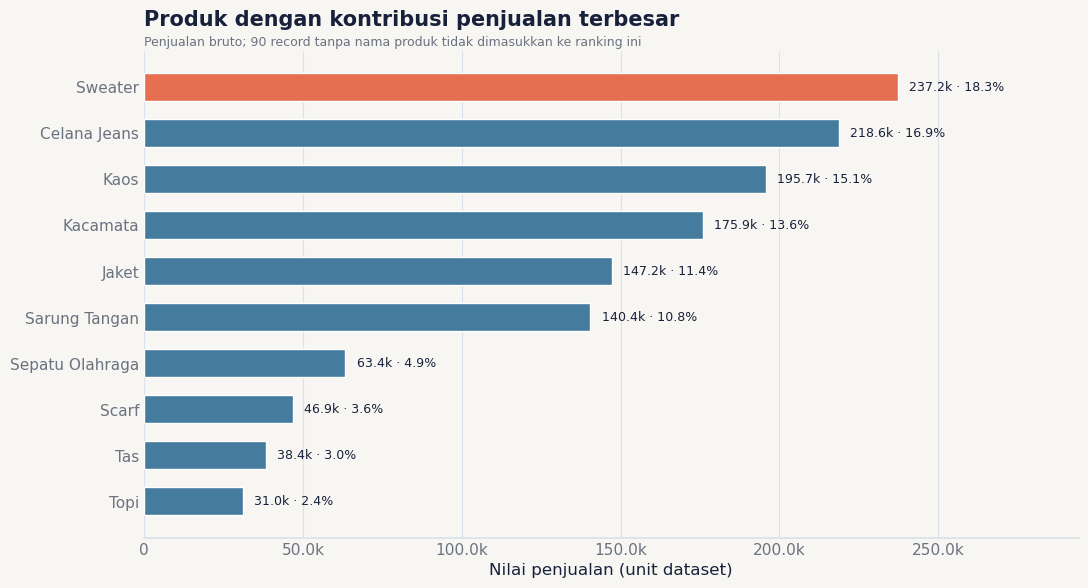

In [6]:
product_plot = known_product_summary.sort_values("Penjualan")
top_product_name = known_product_summary.index[0]
bar_colors = [
    PALETTE["coral"] if name == top_product_name else PALETTE["blue"]
    for name in product_plot.index
]

fig, ax = plt.subplots(figsize=(11, 6), facecolor=PALETTE["paper"])
ax.set_facecolor(PALETTE["paper"])
bars = ax.barh(product_plot.index, product_plot["Penjualan"], color=bar_colors, height=0.62)
ax.set_title("Produk dengan kontribusi penjualan terbesar", loc="left", pad=18)
ax.text(
    0,
    1.01,
    "Penjualan bruto; 90 record tanpa nama produk tidak dimasukkan ke ranking ini",
    transform=ax.transAxes,
    color=PALETTE["muted"],
    fontsize=9,
)
ax.set_xlabel("Nilai penjualan (unit dataset)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: short_number(x)))
clean_axes(ax, "x")
max_value = product_plot["Penjualan"].max()
for bar, (_, row) in zip(bars, product_plot.iterrows()):
    ax.text(
        bar.get_width() + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{short_number(row['Penjualan'])} · {row['Kontribusi (%)']:.1f}%",
        va="center",
        color=PALETTE["ink"],
        fontsize=9,
    )
ax.set_xlim(0, max_value * 1.24)
plt.tight_layout()
plt.show()

### 2. Performa sepanjang waktu

Pertanyaan visual: bagaimana pergerakan penjualan bruto, penjualan bersih, dan return rate dari waktu ke waktu?

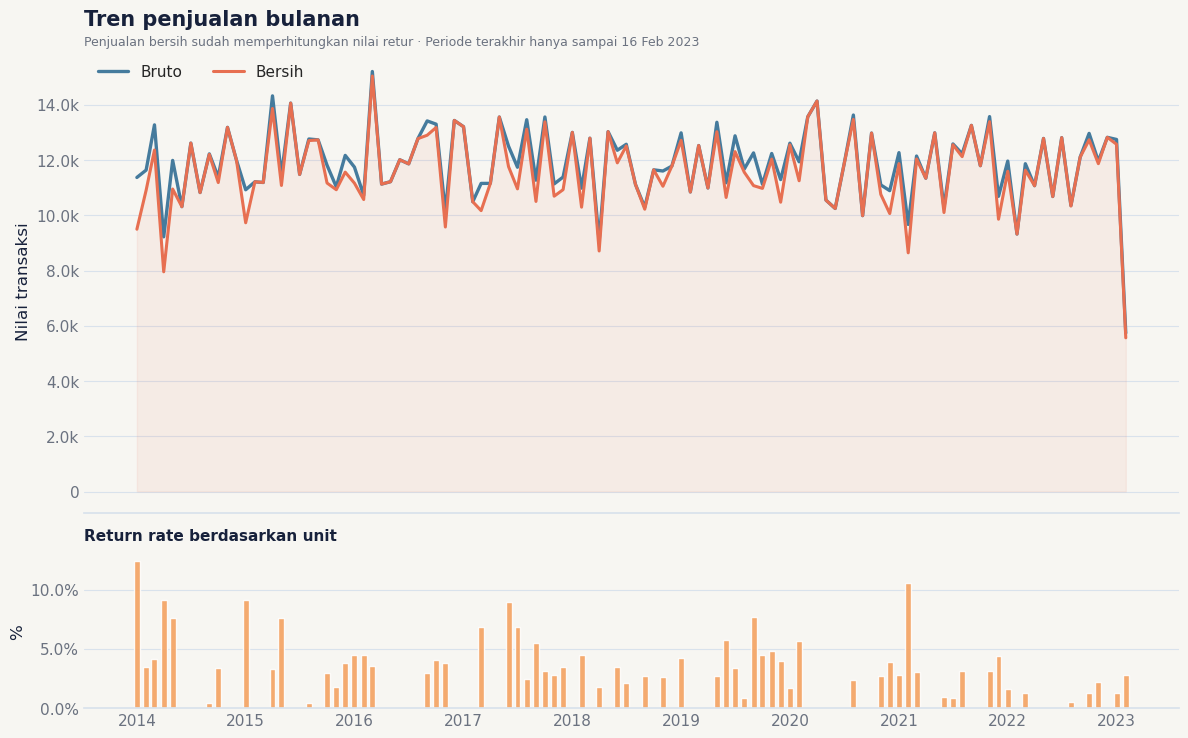

In [7]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 7.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]},
    facecolor=PALETTE["paper"]
)
fig.subplots_adjust(hspace=0.12)

ax1.plot(
    monthly_summary.index,
    monthly_summary["Penjualan Bruto"],
    color=PALETTE["blue"],
    linewidth=2.4,
    label="Bruto",
)
ax1.plot(
    monthly_summary.index,
    monthly_summary["Penjualan Bersih"],
    color=PALETTE["coral"],
    linewidth=2.2,
    label="Bersih",
)
ax1.fill_between(
    monthly_summary.index,
    monthly_summary["Penjualan Bersih"].values,
    color=PALETTE["coral"],
    alpha=0.08,
)
ax1.set_title("Tren penjualan bulanan", loc="left", pad=18)
ax1.text(
    0,
    1.01,
    f"Penjualan bersih sudah memperhitungkan nilai retur · {latest_period_note}",
    transform=ax1.transAxes,
    color=PALETTE["muted"],
    fontsize=9,
)
ax1.set_ylabel("Nilai transaksi")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: short_number(x)))
ax1.legend(frameon=False, loc="upper left", ncol=2)
clean_axes(ax1, "y")

ax2.bar(
    monthly_summary.index,
    monthly_summary["Return Rate (%)"],
    width=20,
    color=PALETTE["gold"],
    alpha=0.9,
)
ax2.set_title("Return rate berdasarkan unit", loc="left", fontsize=11, pad=10)
ax2.set_ylabel("%")
ax2.yaxis.set_major_formatter(PercentFormatter(100))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
clean_axes(ax2, "y")
for label in ax2.get_xticklabels():
    label.set_rotation(0)
plt.tight_layout()
plt.show()

### 3. Lokasi dan segmentasi

Pertanyaan visual: lokasi dan kelompok usia mana yang menyumbang nilai penjualan paling besar?

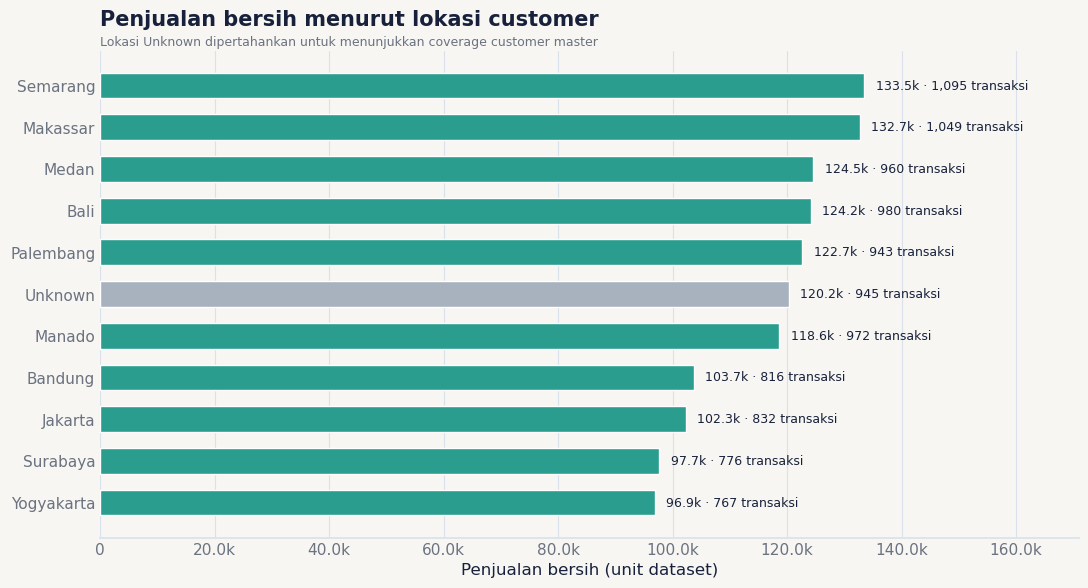

In [8]:
location_plot = location_summary.sort_values("Penjualan Bersih")
location_colors = [
    PALETTE["unknown"] if name == "Unknown" else PALETTE["teal"]
    for name in location_plot.index
]

fig, ax = plt.subplots(figsize=(11, 6), facecolor=PALETTE["paper"])
bars = ax.barh(location_plot.index, location_plot["Penjualan Bersih"], color=location_colors, height=0.62)
ax.set_title("Penjualan bersih menurut lokasi customer", loc="left", pad=18)
ax.text(
    0,
    1.01,
    "Lokasi Unknown dipertahankan untuk menunjukkan coverage customer master",
    transform=ax.transAxes,
    color=PALETTE["muted"],
    fontsize=9,
)
ax.set_xlabel("Penjualan bersih (unit dataset)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: short_number(x)))
clean_axes(ax, "x")
max_location_value = location_plot["Penjualan Bersih"].max()
for bar, (name, row) in zip(bars, location_plot.iterrows()):
    ax.text(
        bar.get_width() + max_location_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{short_number(row['Penjualan Bersih'])} · {int(row['Transaksi Positif']):,} transaksi",
        va="center",
        color=PALETTE["ink"],
        fontsize=9,
    )
ax.set_xlim(0, max_location_value * 1.28)
plt.tight_layout()
plt.show()

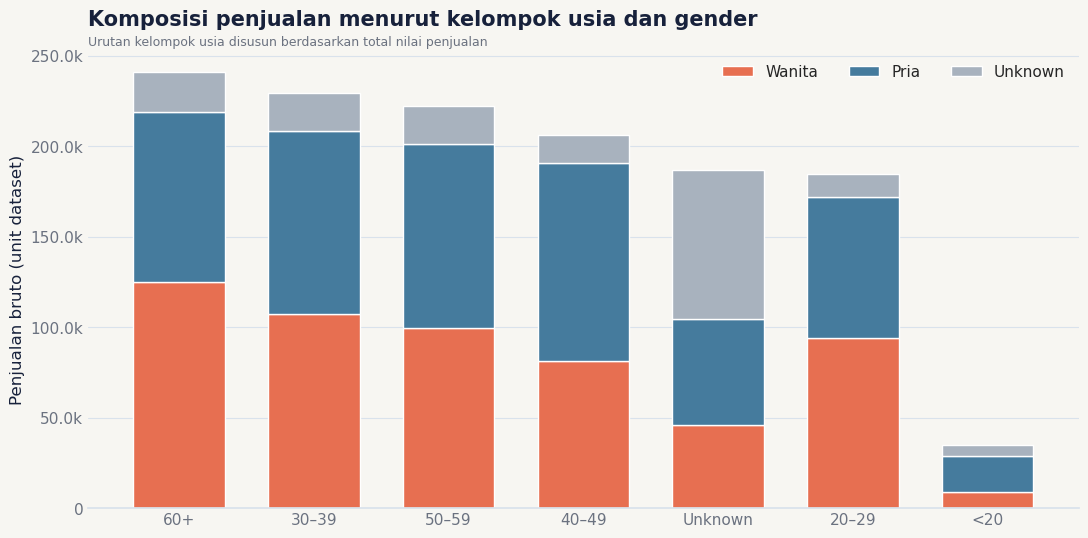

In [9]:
segment_plot = segment_summary.copy()
segment_plot.index = segment_plot.index.astype(str)
segment_plot = segment_plot.loc[segment_plot.sum(axis=1).sort_values(ascending=False).index]
segment_colors = {
    "Wanita": PALETTE["coral"],
    "Pria": PALETTE["blue"],
    "Unknown": PALETTE["unknown"],
}

fig, ax = plt.subplots(figsize=(11, 5.5), facecolor=PALETTE["paper"])
bottom = np.zeros(len(segment_plot))
for gender in ["Wanita", "Pria", "Unknown"]:
    if gender not in segment_plot.columns:
        continue
    values = segment_plot[gender].to_numpy()
    ax.bar(
        segment_plot.index,
        values,
        bottom=bottom,
        color=segment_colors[gender],
        label=gender,
        width=0.68,
    )
    bottom += values
ax.set_title("Komposisi penjualan menurut kelompok usia dan gender", loc="left", pad=18)
ax.text(
    0,
    1.01,
    "Urutan kelompok usia disusun berdasarkan total nilai penjualan",
    transform=ax.transAxes,
    color=PALETTE["muted"],
    fontsize=9,
)
ax.set_ylabel("Penjualan bruto (unit dataset)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: short_number(x)))
ax.legend(frameon=False, ncol=3, loc="upper right")
clean_axes(ax, "y")
plt.tight_layout()
plt.show()

### 4. Product × location

Heatmap ini membantu melihat kombinasi produk-lokasi yang relatif kuat; angka tetap disajikan agar warna tidak menjadi satu-satunya sumber informasi.

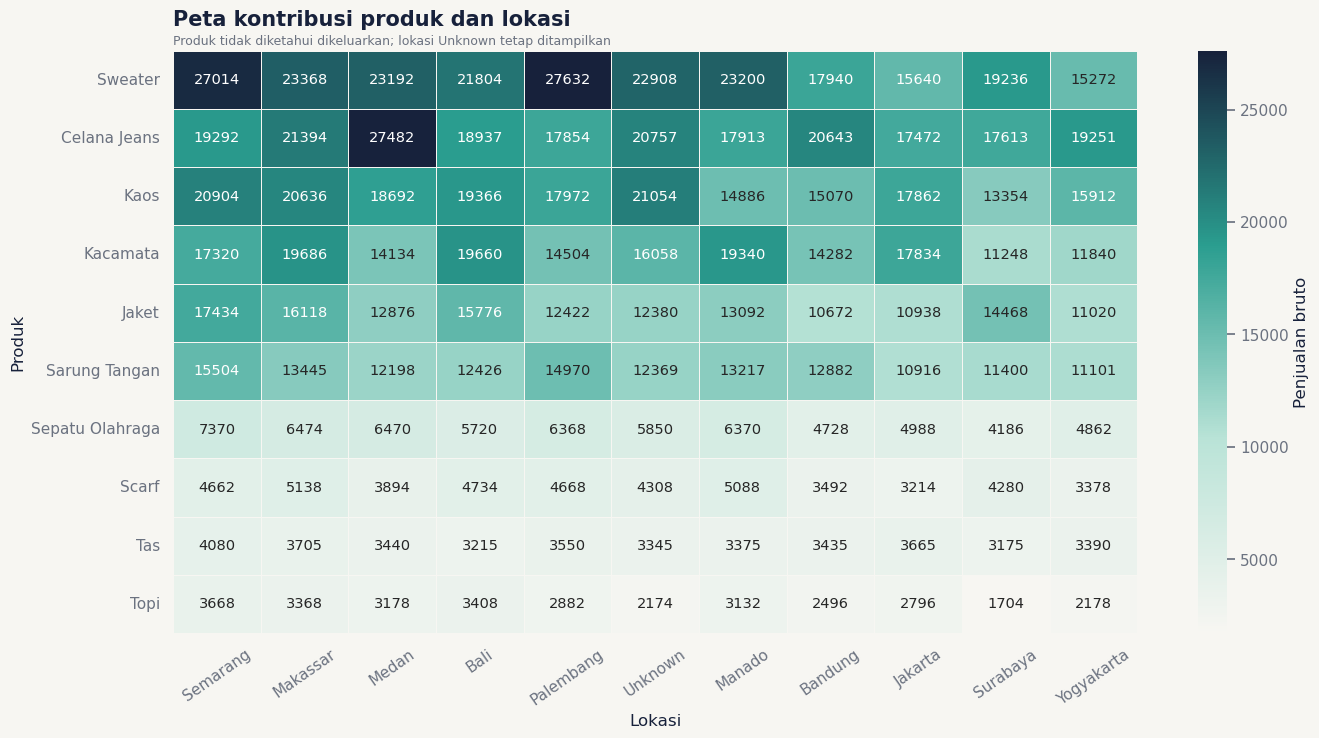

In [10]:
fresh_cmap = LinearSegmentedColormap.from_list(
    "fresh_teal", [PALETTE["paper"], "#B9E3D7", PALETTE["teal"], PALETTE["ink"]]
)
fig, ax = plt.subplots(figsize=(14, 7.5), facecolor=PALETTE["paper"])
sns.heatmap(
    heatmap_data,
    cmap=fresh_cmap,
    annot=True,
    fmt=".0f",
    linewidths=0.6,
    linecolor=PALETTE["paper"],
    cbar_kws={"label": "Penjualan bruto"},
    ax=ax,
)
ax.set_title("Peta kontribusi produk dan lokasi", loc="left", pad=18)
ax.text(
    0,
    1.01,
    "Produk tidak diketahui dikeluarkan; lokasi Unknown tetap ditampilkan",
    transform=ax.transAxes,
    color=PALETTE["muted"],
    fontsize=9,
)
ax.set_xlabel("Lokasi")
ax.set_ylabel("Produk")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

## Takeaways

Kesimpulan di bawah dirakit dari output yang sudah dihitung; bagian ini tetap membedakan temuan deskriptif dari interpretasi bisnis.

In [11]:
top_location_row = location_summary.iloc[0]
top_age_group = segment_summary.sum(axis=1).idxmax()
top_age_value = segment_summary.sum(axis=1).max()
display(
    Markdown(
        f'''
1. **{top_product}** memimpin kontribusi produk sebesar **{top_product_share:.1f}%** di antara produk yang teridentifikasi. Ini menunjukkan konsentrasi penjualan pada SKU tersebut, tetapi belum cukup untuk menyimpulkan penyebabnya.
2. **{top_location}** memiliki nilai penjualan bersih terbesar, sekitar **{format_number(top_location_row['Penjualan Bersih'])}**. Perbandingan ini tetap bersifat deskriptif karena coverage customer master tidak sempurna.
3. Kelompok usia **{top_age_group}** menyumbang nilai penjualan bruto terbesar, sekitar **{format_number(top_age_value)}**. Segmentasi ini sebaiknya dibaca sebagai pola asosiasi, bukan bukti bahwa usia menyebabkan pembelian.
4. Return rate berbasis unit sebesar **{return_rate:.1f}%** perlu dimonitor bersama kualitas data: sumber memiliki **{negative_quantity_rows:,}** record retur dan tidak memiliki transaction ID untuk memastikan apakah **{exact_duplicate_sales_rows:,}** exact duplicates adalah transaksi terpisah atau duplikasi pencatatan.
'''
    )
)


1. **Sweater** memimpin kontribusi produk sebesar **18.3%** di antara produk yang teridentifikasi. Ini menunjukkan konsentrasi penjualan pada SKU tersebut, tetapi belum cukup untuk menyimpulkan penyebabnya.
2. **Semarang** memiliki nilai penjualan bersih terbesar, sekitar **133.506**. Perbandingan ini tetap bersifat deskriptif karena coverage customer master tidak sempurna.
3. Kelompok usia **60+** menyumbang nilai penjualan bruto terbesar, sekitar **240.956**. Segmentasi ini sebaiknya dibaca sebagai pola asosiasi, bukan bukti bahwa usia menyebabkan pembelian.
4. Return rate berbasis unit sebesar **2.2%** perlu dimonitor bersama kualitas data: sumber memiliki **102** record retur dan tidak memiliki transaction ID untuk memastikan apakah **373** exact duplicates adalah transaksi terpisah atau duplikasi pencatatan.


### Caveats sebelum dibagikan ke stakeholder

- Dataset tidak menyebutkan mata uang, sehingga semua nilai diberi label **unit dataset**.
- `customers.csv` memiliki duplicate ID dan beberapa atribut yang konflik. Revisi ini mencegah join menggandakan baris, namun keputusan bisnis yang membutuhkan customer master presisi tetap perlu konfirmasi sumber.
- Customer ID yang tidak ditemukan dan produk yang tidak diketahui dipertahankan sebagai `Unknown` pada total keseluruhan; chart ranking produk mengecualikan produk tidak diketahui agar perbandingan SKU tetap fair.
- Exact duplicate sales rows tidak dihapus karena tidak ada transaction ID. Jika sumber mengonfirmasi bahwa baris tersebut duplikat pencatatan, metrik transaksi dan penjualan perlu dihitung ulang.
- Analisis bersifat deskriptif; notebook ini tidak membuktikan kausalitas, profitabilitas, atau optimalisasi stok karena tidak ada biaya, margin, dan snapshot inventory berbasis waktu.